**Install & Import Libraries**

In [1]:
# !pip install pandas tabula-py
# !java -version
import pandas as pd
import os
import tabula
from tabula.io import read_pdf
import warnings
warnings.filterwarnings("ignore")

**Set the Directory and Specify the PDF Files**

In [2]:
os.chdir("../3.OUT_PDF")
PDF1 = "1.Roozaneh.pdf"
PDF2 = "2.Mahroum.pdf"
PDF3 = "3.Farhangian.pdf"
PDF4 = "4.Kardani_Farhangian.pdf"
PDF5 = "5.Nimeh_Motemarkez.pdf"
PDF6 = "6.Shabaneh.pdf"
PDF7 = "7.Nimeh_Hozouri.pdf"
PDF8 = "8.Payam_Nour.pdf"
PDF9 = "9.Gheir_Entefai.pdf"
PDF10 = "10.Majazi.pdf"

In the **first step**, I begin the process by identifying and storing the headers of each table.
1. Define a list of <span style="color:red">persian keywords</span> that will be used to recognize table headers based on the content of the first column.

<div align="center">

`["دانشگاه", "آموزشكده", "دانشكده", "مجتمع", "مركز", "ادامه"]`

</div>


2. Create a <span style="color:red">dictionary</span> to store the detected headers along with their corresponding row index and page number.

The following image shows an example of how a table header is detected (highlighted in red).

<div align="center">
  <img src="image/1.HEADER.png" width="700"/>
</div>

- Choose PDF 1: (Roozaneh.pdf)

In [3]:
os.chdir("../3.OUT_PDF")
PDF1 = "1.Roozaneh.pdf"

keywords1 = ["دانشگاه", "آموزشكده", "دانشكده", "مجتمع", "مركز", "ادامه"]

uni_headers1 = {}

for page in range(1,23):
    content = tabula.read_pdf(PDF1, lattice = False, guess = False,
                                  pandas_options = {'header': None}, pages = str(page))[0]

    for idx, col in content.iterrows():
        
        if page == 22 and idx >= 36:
            break

        if any(str(cell).startswith(tuple(keywords1)) for cell in col):
            # print( "page:", page, "index:", idx, "university name:", col[0])

            uni_name = str(col[0])
            uni_headers1[(page, idx)] = uni_name

uni_headers1 = list(uni_headers1.items())

uni_headers1[:4] # Test

[((1, 7), 'دانشگاه آيت اله بروجردي-  بروجرد'),
 ((1, 19), 'دانشگاه اراك'),
 ((1, 36), 'دانشگاه اروميه'),
 ((1, 62), 'دانشگاه اصفهان')]

In the **second step**, I continue the process by defining a function that determines which university each row of the table belongs to.

The following function takes 3 inputs:
1. Current Page Number
2. Current Row Index
3. List of header entries

During the process, the function performs the following checks:
- For headers on the same page, the function checks whether the current row index is greater than the header index.
- If this condition is satisfied, the function updates the current university name.

In general, this function returns the <span style="color:red">most recent matching university name</span> for the given row.

In [4]:
def find_university(page, idx, header_items):
    current_uni = None
    
    for (h_page, h_idx), h_name in header_items:
        if h_page < page:
            continue

        if h_page > page:
            break

        if idx > h_idx:
            current_uni = h_name
        else:
            break
        
    return current_uni

In the **third step**, I continue the process by identifying and storing the desired rows from each table.
1. Identify rows that begin with a number.
2. Apply the `find_university` function for matching.
3. Change the merged cells manually.
4. Store the resulting rows to create a dataset.

The following image shows an example of how the rows is detected (highlighted in red).

<div align="center">
  <img src="image/2.ROW.png" width="700"/>
</div>

In [5]:
page_list1 = []

for page in range(1,23):
    content = tabula.read_pdf(PDF1, lattice = False,
                               guess = False, columns = [205, 233, 261, 290, 318, 389, 531],
                              pandas_options = {'header': None}, pages = str(page))[0]
    university = ''

    for idx, col in content.iterrows():

        if str(col[7]).isdigit():
            idx_prim = idx - 1 if (8 <= page <= 11 or 13 <= page <= 15 or page == 17 or 19 <= page <= 20) else idx
            university = find_university(page, idx_prim, uni_headers1)
            row_list = list(col.values)
            row_list += [university] 
            row_list.reverse()
            if page == 7 and row_list[1] == "1465":
                row_list[3] = "الکترونیک، بیوالکتریک، قدرت، کنترل، مخابرات"
            if page == 8 and row_list[1] == "1530":
                row_list[8] = "گرايش حالت جامد - محل تحصيل كرج )عدم واگذاري خوابگاه به پسران("
            if page == 10 and row_list[1] == "1627" or row_list[1] == "1633":
                row_list[3] = "الكترونيك, قدرت, كنترل, مخابرات"
            if page == 11 and row_list[1] == "1679":
                row_list[3] == "اتمـــي, حالـــت جامـــد, هسته اي"
            if page == 12 and row_list[1] == "1708" or row_list[1] == "1746":
                row_list[3] = "الكترونيك, قدرت, كنترل, مخابرات"
            if page == 13 and row_list[1] == "1824":
                row_list[3] = "الكترونيك, قدرت, كنترل, مخابرات"
            if page == 14 and row_list[1] == "1849":
                row_list[3] = "الكترونيـــك, بيوالكتريـــك, قــدرت, كنتــرل, مخــابرات, سيستمهاي ديجيتال"
            if page == 15 and row_list[1] == "1893":
                row_list[3] = "الكترونيك, قدرت, كنترل, مخابرات"
            if page == 16 and row_list[1] == "1956":
                row_list[3] = "الكترونيك, قدرت, كنترل, مخابرات"
            if page == 17 and row_list[1] == "2016":
                row_list[8] = "محـل تحـصيل مركزآمـوزش عـالي كوهدشـت - اسـتفاده از غـذاخوري دانشگاه بصورت آزاد و فاقد خوابگاه"
            if page == 17 and row_list[1] == "2025":
                row_list[8] = "محل تحصيل مركز آموزش عالي الشتر- اسـتفاده از غـذاخوري دانـشگاه بصورت آزاد و فاقد خوابگاه"
            if page == 17 and row_list[1] == "2026":
                row_list[8] = "محل تحصيل مركز آموزش عالي پلدختر- استفاده از غـذاخوري دانـشگاه بصورت آزاد و فاقد خوابگاه"
            if page == 17 and row_list[1] == "6877" or row_list[1] == "6878" or row_list[1] == "6879":
                row_list[0] = "دانشگاه لرستان - خرم آباد"
            if page == 17 and row_list[1] == "6884" or row_list[1] == "6885" or row_list[1] == "6886":
                row_list[0] = "دانشگاه مازندران - بابلسر"
            if page == 19 and row_list[1] == "2125":
                row_list[3] = "الكترونيــــك, قــــدرت, مخابرات"
            if page == 19 and row_list[1] == "2139":
                row_list[2] = "کاردانی علمی کاربردی ماشینهای کشاورزی-مکانیزاسیون ماشینهای کشاورزی"
            if page == 22 and str(col[7]) == "2223":
                break
            # print(idx, row_list) 
            page_list1.append(row_list)

Convert extracted tables into a DataFrame with labeled columns

In [6]:
df1 = pd.DataFrame(page_list1, columns = ['University', 'Program-Code', 'Program-Major-Name', 'Field-Type',
                           'First-Cap', 'Second-Cap', 'Female-Cap', 'Male-Cap', 'Description'])

df1.head(5) # Test

,University,Program-Code,Program-Major-Name,Field-Type,First-Cap,Second-Cap,Female-Cap,Male-Cap,Description
0,دانشگاه آيت اله بروجردي- بروجرد,1001,رياضيات وكاربردها,NaN,40,-,زن,مرد,NaN
1,دانشگاه آيت اله بروجردي- بروجرد,1002,فيزيك,NaN,40,-,زن,مرد,NaN
2,دانشگاه آيت اله بروجردي- بروجرد,1003,مهندسي عمران,NaN,40,-,زن,مرد,NaN
3,دانشگاه آيت اله بروجردي- بروجرد,1004,مهندسي كامپيوتر,نرم افزار,40,-,زن,مرد,NaN
4,دانشگاه آيت اله بروجردي- بروجرد,6701,علوم اقتصادي,اقتصادبازرگاني,40,-,زن,مرد,NaN


Save the DataFrame as a CSV file in the **"OUT_TABLE"** folder.

In [7]:
os.chdir("../4.OUT_TABLE")
df1.to_csv("1.Roozaneh.csv", index = False, encoding = "utf-8-sig")

---

- Choose PDF 2: (Mahroum.pdf)

In [8]:
os.chdir("../3.OUT_PDF")
PDF2 = "2.Mahroum.pdf"

keywords2 = ["مخصوص", "ادامه"]

uni_headers2 = {}

for page in range(1,3):
    content = tabula.read_pdf(PDF2, lattice = False, guess = False,
                                  pandas_options = {'header': None}, pages = str(page))[0]

    for idx, col in content.iterrows():

        if any(str(cell).startswith(tuple(keywords2)) for cell in col):
            # print( "page:", page, "index:", idx, "university name:", col[0])
            
            uni_name = str(col[0])
            uni_headers2[(page, idx)] = uni_name

uni_headers2 = list(uni_headers2.items())

uni_headers2[:5] # Test

[((1, 29), 'مخصوص داوطلبان بومي استان ايلام'),
 ((1, 41), 'مخصوص داوطلبان بومي استان بوشهر'),
 ((1, 47), 'مخصوص داوطلبان بومي استان چهارمحال و بختياري'),
 ((1, 53), 'مخصوص داوطلبان بومي استان سيستان و بلوچستان'),
 ((1, 67), 'مخصوص داوطلبان بومي استان كردستان')]

In [9]:
page_list2 = []
start_row = False

for page in range(1,3):
    content = tabula.read_pdf(PDF2, lattice = False,
                               guess = False, columns = [205, 233, 261, 290, 318, 389, 531],
                              pandas_options = {'header': None}, pages = str(page))[0]
    university = ''

    for idx, col in content.iterrows():

        if str(col[7]).isdigit():
            university = find_university(page, idx, uni_headers2)
            row_list = list(col.values)
            row_list += [university] 
            row_list.reverse()

            if not start_row:
                if row_list[1] == "2223":
                    start_row = True
                else:
                    continue

            if page == 1 and row_list[1] == "2237":
                row_list[8] = "دانشگاه اصفهان ـ با سپردن تعهد خدمت بـه معاونـت درمـان دانشگاه علوم پزشكي زاهدان"
            if page == 1 and row_list[1] == "2243":
                row_list[2] = "مهندسی کشاورزی-مکانیک ماشینهای کشاورزی"
            if page == 1 and row_list[1] == "7074":
                row_list[0] = "مخصوص داوطلبان بومي استان سيستان و بلوچستان"
            if page == 1 and row_list[1] == "2249":
                row_list[0] = "مخصوص داوطلبان بومي استان كردستان"
            if page == 2 and row_list[1] == "2281":
                row_list[3] = "الكترونيك, قدرت, كنترل, مخابرات"

            # print(idx, row_list) 
            page_list2.append(row_list)

In [10]:
df2 = pd.DataFrame(page_list2, columns = ['University', 'Program-Code', 'Program-Major-Name', 'Field-Type',
                           'First-Cap', 'Second-Cap', 'Female-Cap', 'Male-Cap', 'Description'])

df2.head(5) # Test

,University,Program-Code,Program-Major-Name,Field-Type,First-Cap,Second-Cap,Female-Cap,Male-Cap,Description
0,مخصوص داوطلبان بومي استان ايلام,2223,مهندسي برق,قدرت,5,-,1,4,دانشگاه ايلام
1,مخصوص داوطلبان بومي استان ايلام,2224,مهندسي شيمي,NaN,2,-,1,1,دانشگاه ايلام
2,مخصوص داوطلبان بومي استان ايلام,2225,مهندسي عمران,NaN,2,-,1,1,دانشگاه ايلام
3,مخصوص داوطلبان بومي استان ايلام,2226,مهندسي فناوري اطلاعات,NaN,2,-,1,1,دانشگاه ايلام
4,مخصوص داوطلبان بومي استان ايلام,2227,مهندسي كامپيوتر,نرم افزار,2,-,1,1,دانشگاه ايلام


In [11]:
os.chdir("../4.OUT_TABLE")
df2.to_csv("2.Mahroum.csv", index = False, encoding = "utf-8-sig")

---

- Choose PDF 3: (Farhangian.pdf)

In [ ]:
os.chdir("../3.OUT_PDF")
PDF3 = "3.Farhangian.pdf"

keywords = ["مخصوص", "ادامه"]

uni_headers = {}

for page in range(1, 4):
    content = tabula.read_pdf(PDF3, lattice = False, guess = False,
                                  pandas_options = {'header': None}, pages = str(page))[0]

    for idx, col in content.iterrows():

        if page == 3 and idx >= 55:
            break

        if any(str(cell).startswith(tuple(keywords)) for cell in col):
            # print( "page:", page, "index:", idx, "university name:", col[0])
            
            uni_name = str(col[0])
            uni_headers[(page, idx)] = uni_name

uni_headers = list(uni_headers.items())

uni_headers[:5]

---

- Choose PDF 4: (Kardani-Farhanian.pdf)

This PDF does not have any header, making it easy to iterate through the rows to extract the table.

The area of this table has been modified to easily separate the cells. 

The same above pattern is also present here.

The following image shows an example of how I iterate through the rows:

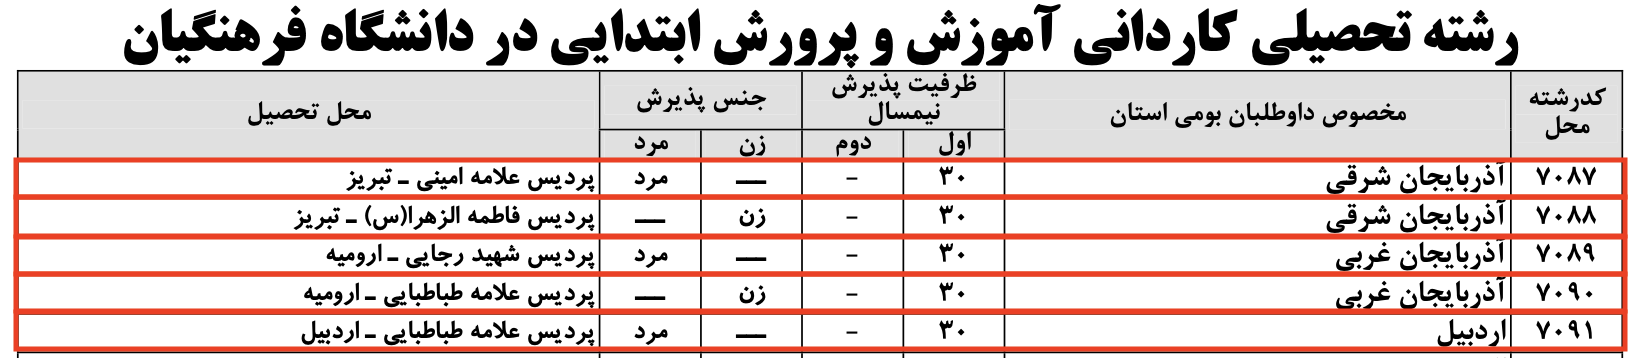

In [ ]:
os.chdir("../3.OUT_PDF")
pdf4 = "4-Kardani-Farhanian.pdf"

kardani_farhangian_list = []

for page in range(1, 3):
    content = tabula.read_pdf(pdf4, lattice = False,
                               guess = False, columns = [236, 264, 293, 321, 349, 491, 522],
                              pandas_options = {'header': None}, pages = str(page))[0]

    for idx, col in content.iterrows():

        if str(col[6]).isdigit():
            row_list = list(col.values)
            row_list.reverse()
            row_list = row_list[+1:]
            # print(row_list) 
            kardani_farhangian_list.append(row_list)

df4 = pd.DataFrame(kardani_farhangian_list,
                   columns = ["Programme-Code", "Province", "Capacity-first",
                               "Capacity-Second", "Female-Cap", "Male-Cap", "Location"])

df4.head(5)
            

Save this file as a CSV in the **"OUT_TABLE"** folder.

In [ ]:
os.chdir("../4.OUT_TABLE")
df4.to_csv("4.Kardani-Farhangian.csv", index = False, encoding = "utf-8-sig")

---

- Choose PDF 7: (Nimeh-Hozouri.pdf)

This PDF does not have any header, making it easy to iterate through the rows to extract the table.

The area of this table has been modified to easily separate the cells. 

The same above pattern is also present here.

The following image shows an example of how I iterate through the rows:

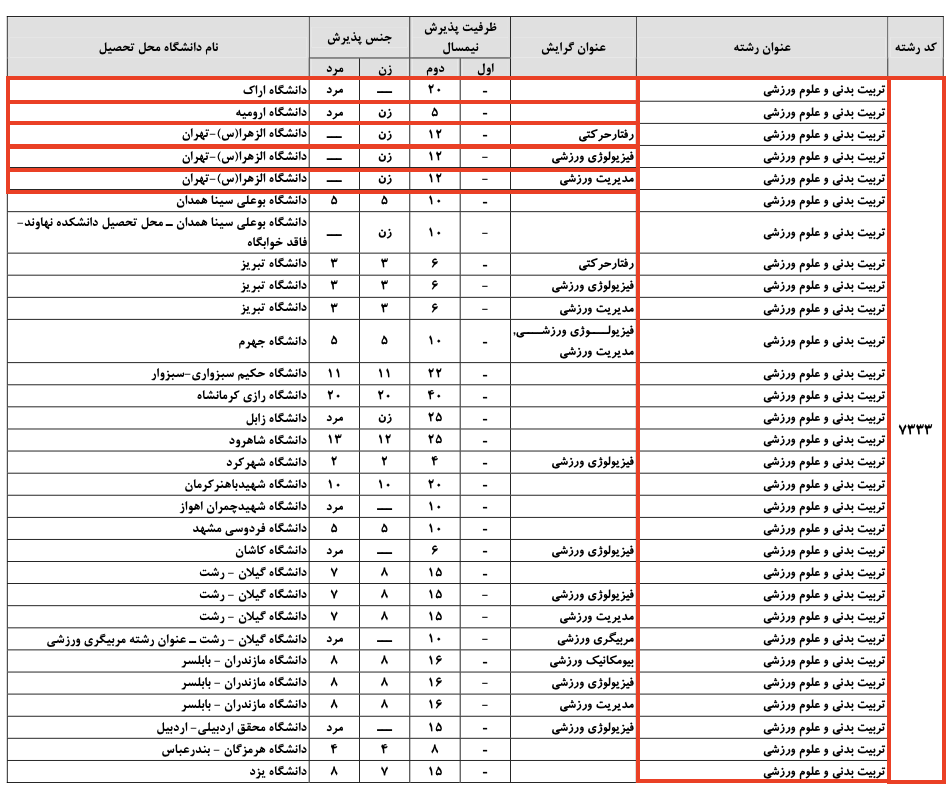

In [ ]:
os.chdir("../3.OUT_PDF")
pdf7 = "7-Nimeh_Hozouri.pdf"

nimeh_hozouri_list = []

for page in range(1, 3):
    content = tabula.read_pdf(pdf7, lattice = False,
                               guess = False, columns = [204, 233, 261, 289, 317, 389, 530],
                              pandas_options = {'header': None}, pages = str(page))[0]
    if page == 1:

        for idx, col in content.iterrows():

            if str(col[6]) == "تربيت بدني و علوم ورزشي":
                row_list = list(col.values)
                row_list.reverse()
                row_list[0] = 7333
                if pd.isna(row_list[7]):
                    row_list[7] = "دانشگاه بوعلي سينا همدان ـ محل تحصيل دانشكده نهاوند-فاقد خوابگاه"
                if row_list[7] == "دانشگاه جهرم":
                    row_list[2] = "فيزيولــــوژي ورزشــــي, مديريت ورزشي"
                # print(row_list)
                nimeh_hozouri_list.append(row_list)
    
    else:
        for idx, col in content.iterrows():

            if str(col[7]).isdigit():
                row_list = list(col.values)
                row_list.reverse()
                if row_list[0] == "7363" or row_list[0] == "7364" or row_list[0] == "7365":
                    row_list[7] = "دانشگاه اروميه"
                if row_list[0] == "7366":
                    row_list[7] = "دانشگاه علامه طباطبايي - تهران"
                if row_list[0] == "7367":
                    row_list[7] = "دانشگاه كردستان - سنندج"
                if row_list[0] == "7368":
                    row_list[7] = "موسسه اموزشي وپژوهشي امام خميني)ره(- قم"
                # print(row_list)
                nimeh_hozouri_list.append(row_list)


df7 = pd.DataFrame(nimeh_hozouri_list,
                   columns = ["Programme-Code", "Programme-Major-Name", "Major-Type",
                               "Capacity-first", "Capacity-Second", "Female-Cap", "Male-Cap", "University Location"])
df7.head(5)

Save this file as a CSV in the **"OUT_TABLE"** folder.

In [ ]:
os.chdir("../4.OUT_TABLE")
df7.to_csv("7.Nimeh-Hozouri.csv", index = False, encoding = "utf-8-sig")

---

- Choose PDF 10: (Majazi.pdf)

In [ ]:
os.chdir("../3.OUT_PDF")
pdf10 = "10-Majazi.pdf"

keywords = ["دانشگاه", "موسسه"]

uni_headers = {}

for page in range(1, 2):
    content = tabula.read_pdf(pdf10, lattice = False, guess = False,
                                  pandas_options = {'header': None}, pages = str(page))[0]

    for idx, col in content.iterrows():

        if any(str(cell).startswith(tuple(keywords)) for cell in col):
            # print( "page:", page, "index:", idx, "university name:", col[0])

            uni_name = str(col[0])
            uni_headers[(page, idx)] = uni_name

uni_headers = list(uni_headers.items())

uni_headers[:5]

In [ ]:
def find_university(page, idx, header_items):
    current_uni = None
    for (h_page, h_idx), h_name in header_items:
        if h_page < page:

            continue
        if h_page > page:

            break

        if idx >= h_idx:
            current_uni = h_name
        else:
            break
    return current_uni

In [ ]:
majazi_list = []

for page in range(1, 2):
    content = tabula.read_pdf(pdf10, lattice = False,
                               guess = False, columns = [205, 233, 261, 290, 318, 389, 531],
                              pandas_options = {'header': None}, pages = str(page))[0]
    university = ''

    for idx, col in content.iterrows():

        if str(col[7]).isdigit():
            university = find_university(page, idx, uni_headers)
            row_list = list(col.values)
            # row_list = row_list[+1:] 
            row_list += [university] 
            row_list.reverse()
            if row_list[1] == "4972" or row_list[1] == "4973" or row_list[1] == "4974" or row_list[1] == "4975" or row_list[1] == "4976" or row_list[1] == "4977":
                row_list[8] = "محل تحصيل دانشكده آموزش هاي الكترونيكي"
            
            if row_list[1] == "4983" or row_list[1] == "4984" or row_list[1] == "4985" or row_list[1] == "4986" or row_list[1] == "4987":
                row_list[8] = "پذيرش ازطريق پرديس بين الملل دانشگاه صنعتي شريف\nدر جزيره كيش- محل تحصيل تهران"
            # print(row_list)
            majazi_list.append(row_list)


df10 = pd.DataFrame(majazi_list, columns = ['university', 'Programme-Code', 'Programme-Major-Name', 'Major-Type',
                           'Capacity-first', 'Capacity-Second', 'Female-Cap', 'Male-Cap', "Description"])

df10.head(5)

In [ ]:
os.chdir("../4.OUT_TABLE")
df10.to_csv("10.Majazi.csv", index = False, encoding = "utf-8-sig")

In [ ]:
for page in range(1,2):
    content = tabula.read_pdf(pdf1, lattice = False, guess = False, columns = [205, 233, 261, 290, 318, 389, 531],
                                  pandas_options={'header': None}, pages = str(page))[0]
    page_list = []
    university = ''
    for idx, rowcol in content.iterrows():
        if rowcol[7] == "محل":
            row_after = content.iloc[idx+2:]

            stop_idx = row_after.index[row_after.iloc[:, 4].eq("صفحه")]
            if len(stop_idx):
                row_after = row_after.loc[:stop_idx[0] - 1]

            for _, r in row_after.iterrows():
                row_list = list(r.values)
                print(row_list)

In [ ]:
pfx = ["دانشگاه", "آموزشكده", "دانشكده", "مجتمع", "مركز", "ادامه"]

for page in range(40, 41):
    content = tabula.read_pdf(path, lattice = False, guess = False, columns = [205, 233, 261, 290, 318, 389, 531],
                                  pandas_options={'header': None}, pages = str(page))[0]
    page_list = []
    university = ''
    for idx, rowcol in content.iterrows():
        # # print("hello", index)
        # if rowcol.isna().sum() >= 1 and rowcol[7] != "محل":

        #     uni_header = ''
            
        #     for i in range(7, -1, -1):
        #         if type(rowcol[i]) == str:
        #             uni_header += rowcol[i]
        #     if any(uni_header.strip().startswith(prefix) for prefix in pfx):
        #     # if "دانشگاه" in uni_header or "آموزشكده" in uni_header or "دانشكده" in uni_header or "مجتمع" in uni_header or "مركز" in uni_header:
        #         university = uni_header
                # print("Page:", pp, "Row Number:", index, "Uni Name:", university)

            #################################

        if rowcol[7] == "محل":
            row_after = content.iloc[idx+2:]

            stop_idx = row_after.index[row_after.iloc[:, 4].eq("صفحه")]
            if len(stop_idx):
                row_after = row_after.loc[:stop_idx[0] - 1]

            for _, r in row_after.iterrows():
                row_list = list(r.values)
                row_list += [university]
                row_list.reverse()

                code_col = row_list[1]

                # if str(code_col).isdigit():
                    # code_col = int(code_col)
                # print(code_col)


                ##########################

                # if code_col.startswith("1","2","3","4","5","6","7","8","9","0") or code_col == "nan":
                #     row_list = row_list

                ##########################



                page_list.append(row_list)
                print(row_list)
                
                # print(page_list[-1])


In [ ]:
content

In [ ]:
for pp in range(20, 42):
    content = tabula.read_pdf(path, lattice=False, guess=False,
                              columns=[205, 233, 261, 290, 318, 389, 531],
                              pandas_options={'header': None}, pages=str(pp))[0]
    page_list = []
    university = ''
    print("page", pp)
    
    for index, rowcol in content.iterrows():
        if rowcol.isna().sum() >= 1 and rowcol[7] != "محل":
            uni_header = ''
            for i in range(7, -1, -1):
                if isinstance(rowcol[i], str):
                    uni_header += rowcol[i]

            if uni_header.strip().startswith(("دانشگاه", "ادامه دانشگاه")):
                university = uni_header.strip()
                print(index, university)

In [ ]:
df = pd.DataFrame(columns=['university', 'Programme-Code', 'Programme-Major-Name', 'Major-Type',
                           'Capacity-first', 'Capacity-Second', 'Female-Cap', 'Male-Cap', 'Notes'])
for pp in range(20, 21):
  content = tabula.read_pdf(path, lattice = False, guess = False, columns = [205, 233, 261, 290, 318, 389, 531],
                                  pandas_options={'header': None}, pages = str(pp))[0]
  page_list = []
  university = ''
  for index, row in content.iterrows():
    if row[7] == "محل":
        row_after = content.iloc[index+2:]

        for _, r in row_after.iterrows():
            row_list = list(r.values)
            row_list += [university]
            row_list = row_list[::-1]
            page_list += [row_list]
    # elif pd.isna(row[7]) and pd.isna(row[6]):
    elif row.isna().sum() >= 6: 
      temp_university = ''
      for i in range(7, -1, -1):
        if type(row[i]) == str:
          temp_university += row[i]
      if "دانشگاه" in temp_university:
        university = temp_university
  df1 = pd.DataFrame(page_list, columns=['university', 'Programme-Code', 'Programme-Major-Name', 'Major-Type',
                            'Capacity-first', 'Capacity-Second', 'Female-Cap', 'Male-Cap', 'Notes'])
  df = pd.concat([df, df1], ignore_index = True)


In [ ]:
for pp in range(20, 21):
  content = tabula.read_pdf(path, lattice = False, guess = False, columns = [205, 233, 261, 290, 318, 389, 531],
                                  pandas_options={'header': None}, pages = str(pp))[0]
  page_list = []
  university = ''

  for index, row in content.iterrows():
    if row[7] == "محل":
        row_after = content.iloc[index+2:]

        for _, r in row_after.iterrows():
            row_list = list(r.values)
            row_list += [university]
            row_list = row_list[::-1]
            page_list += [row_list]
            
            if r.isna().sum() >= 5 and r[7] != "محل":
              print('test')
              # temp_university = ''
              # for i in range(7, -1, -1):
              #   if type(row[i]) == str:
              #     print('hello')
              #     temp_university += row[i]
              #     print('tmp university so far:', temp_university)
              #   if "دانشگاه" in temp_university:
              #     print("temp_university:", temp_university)
              #     print(30*'-')
              #     university = temp_university
            # print(page_list)

    # elif pd.isna(row[7]) and pd.isna(row[6]): 
    if row.isna().sum() >= 3:
      temp_university = ''
      for i in range(7, -1, -1):
        if type(row[i]) == str:
          temp_university += row[i]
      if "دانشگاه" in temp_university:
        # print("temp_university:", temp_university)
        university = temp_university
        print(index)
        print("university:", university)
    